In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.metrics import roc_curve

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

Number of features in X_train: 84
Best number of features according to RFECV: 79
[RFECV] Mean CV AUC at k=20: 0.734242


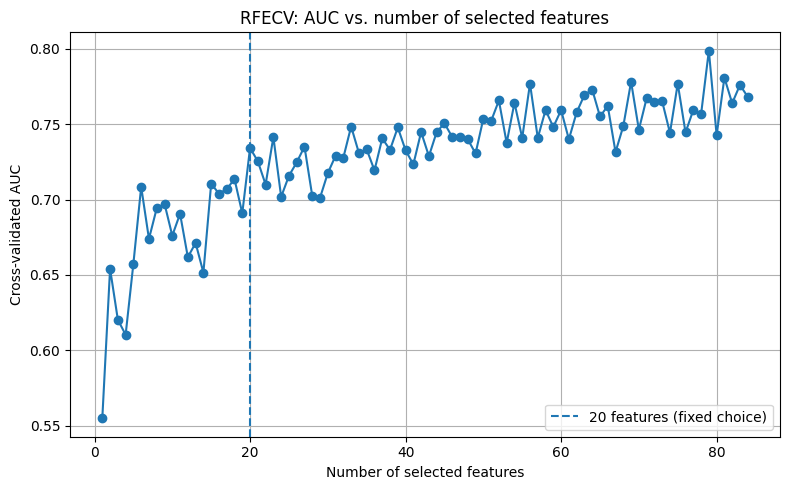

In [6]:
# =========================
# 1) Global reproducibility settings
# =========================
RANDOM_STATE = 42

# Fix Python's built-in RNG
random.seed(RANDOM_STATE)

# Fix NumPy RNG
np.random.seed(RANDOM_STATE)

# (Optional) Hash seed – helps with some subtle sources of randomness
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

# =========================
# 2) Load Train / Test data
# =========================
# XGB-wrapper feature space (84 features)
X_train = pd.read_csv("../data/X_train_xgbsel.csv")
X_test  = pd.read_csv("../data/X_test_xgbsel.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

# =========================
# 3) RFECV train + plot
# =========================

def make_rf(seed: int = 42):
    """CPU-based RandomForest with fixed hyperparameters (single-threaded for determinism)."""
    return RandomForestClassifier(
        n_estimators=150,     # fixed number of trees
        max_depth=12,         # maximum depth of each tree
        min_samples_leaf=2,   # minimum samples per leaf
        bootstrap=True,       # use bootstrap sampling
        n_jobs=1,             # single core to avoid parallel nondeterminism
        random_state=seed,    # random seed for reproducibility
    )

# RFECV setup (allow down to 1 feature to see the full curve)
rf_for_rfe = make_rf(seed=RANDOM_STATE)

cv_sel = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,  # fixed CV splits
)

rfecv = RFECV(
    estimator=rf_for_rfe,       # CPU-based RandomForest with fixed hyperparameters
    step=1,                     # remove one feature at each step
    cv=cv_sel,
    scoring="roc_auc",
    n_jobs=1,                   # single core for RFECV as well
    min_features_to_select=1,   # allow down to 1 feature so we can plot the full curve
)

# Fit RFECV on the training data
rfecv.fit(X_train, y_train)

print("Number of features in X_train:", rfecv.n_features_in_)
print("Best number of features according to RFECV:", rfecv.n_features_)

# Get RFECV scores for plotting (newer vs older scikit-learn)
try:
    # Newer versions: use cv_results_
    mean_scores = rfecv.cv_results_["mean_test_score"]
    n_features = rfecv.cv_results_["n_features"]
except AttributeError:
    # Older versions: use grid_scores_ (deprecated but still works)
    mean_scores = rfecv.grid_scores_
    n_total = rfecv.n_features_in_
    min_feat = rfecv.min_features_to_select
    step = rfecv.step
    # Reconstruct the number of features for each step
    n_features = np.arange(n_total, min_feat - 1, -step)[::-1]

# --- Print CV AUC at exactly 20 features (if available) ---
target_k = 20
idx = np.where(np.asarray(n_features) == target_k)[0]
if idx.size == 0:
    print(f"[RFECV] No exact entry for k={target_k}. Available k range: "
          f"{np.min(n_features)}..{np.max(n_features)}")
else:
    auc20 = float(np.asarray(mean_scores)[idx[0]])
    print(f"[RFECV] Mean CV AUC at k={target_k}: {auc20:.6f}")


# Plot AUC vs number of selected features
plt.figure(figsize=(8, 5))
plt.plot(n_features, mean_scores, marker="o")
plt.axvline(x=20, linestyle="--", label="20 features (fixed choice)")
plt.xlabel("Number of selected features")
plt.ylabel("Cross-validated AUC")
plt.title("RFECV: AUC vs. number of selected features")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


We applied RFECV with a Random Forest (150 trees, max_depth=12, min_samples_leaf=2) on the 84 XGBoost-selected radiomic features. 
Figure X shows the cross-validated AUC as a function of the number of selected features. 
The curve increases rapidly when going from very small subsets to around 20 features, and then continues to improve more gradually as additional features are added. 
Although the highest AUC is achieved with a larger number of features, the marginal gain beyond 20 features is relatively small. 
To balance predictive performance, model complexity, and interpretability, we therefore fixed the feature subset size to 20 for all subsequent experiments and selected the top-20 features according to the RFECV ranking.


In [3]:
# Select the top-20 features according to the RFECV ranking
ranking = rfecv.ranking_          # 1 = best, larger = worse
top20_idx = np.argsort(ranking)[:20]
top20_features = X_train.columns[top20_idx]

print("Selected top-20 features:")
for f in top20_features:
    print(" -", f)

# Build reduced train/test matrices
Xtr_sub = X_train.iloc[:, top20_idx].values
Xte_sub = X_test.iloc[:, top20_idx].values


Selected top-20 features:
 - VOLUME_NET_OVER_WT
 - TEXTURE_GLRLM_ED_T1Gd_LGRE
 - TEXTURE_GLSZM_NET_FLAIR_LZHGE
 - SOLIDITY_ED
 - TEXTURE_GLCM_NET_T2_Contrast
 - HISTO_ET_FLAIR_Bin5
 - TEXTURE_GLRLM_ED_T2_GLN
 - TEXTURE_GLCM_ET_FLAIR_Energy
 - HISTO_ET_T1_Bin5
 - HISTO_ED_T1Gd_Bin7
 - HISTO_NET_T1_Bin1
 - TEXTURE_GLSZM_ED_T2_LGZE
 - HISTO_NET_FLAIR_Bin10
 - TEXTURE_GLRLM_ED_FLAIR_HGRE
 - TEXTURE_GLCM_ET_FLAIR_Dissimilarity
 - HISTO_ED_FLAIR_Bin10
 - HISTO_NET_T2_Bin7
 - TEXTURE_GLCM_ED_T2_Variance
 - SPATIAL_Temporal
 - SPATIAL_Insula


In [4]:
selected_idx = top20_idx


print("Number of selected (non-zero) features:", len(selected_idx))
selected_features = X_train.columns[selected_idx]
print("\nSelected features by L1-SVM (best C):")
for f in selected_features:
    print(" -", f)

# ============================================
# 2. RF tuning setup (now tuning n_estimators too)
# ============================================
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)  # use the same global setting if defined
RANDOM_STATE  = 42

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

def tune_rf_for_features(feature_idx, label):
    """
    Given a feature subset (column indices), run RandomizedSearchCV
    for RF tuning with similar settings as in the GA-RF pipeline,
    but now also tuning n_estimators.
    """
    # Subset the training data to the given feature indices
    X_sub = X_train.iloc[:, feature_idx].to_numpy()

    # Base RF model; let RandomizedSearchCV tune n_estimators, etc.
    base_rf = RandomForestClassifier(
        random_state=2042,
        n_jobs=-1
    )

    # RandomizedSearchCV over the hyperparameters
    rs = RandomizedSearchCV(
        estimator=base_rf,
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0
    )
    rs.fit(X_sub, y_train)

    best_params = dict(rs.best_params_)
    # Clean up keys that are not needed when creating the final RF
    best_params.pop("random_state", None)
    best_params.pop("n_jobs", None)
    if best_params.get("bootstrap") is False:
        best_params.pop("max_samples", None)

    print(f"\n[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params, float(rs.best_score_)

# ============================================
# 3. RF tuning using the L1-SVM top-k features (non-zero coef)
# ============================================
label = "RF (L1-SVM top-22 features)"
best_params, cv_auc_best = tune_rf_for_features(selected_idx, label)

# ============================================
# 4. Refit on full TRAIN and report TRAIN / TEST AUC
# ============================================
Xtr_sub = X_train.iloc[:, selected_idx].to_numpy()
Xte_sub = X_test.iloc[:,  selected_idx].to_numpy()

rf_final = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params   # includes n_estimators, max_depth, etc.
)
rf_final.fit(Xtr_sub, y_train)

# Train / Test predicted probabilities
prob_tr = rf_final.predict_proba(Xtr_sub)[:, 1]
prob_te = rf_final.predict_proba(Xte_sub)[:, 1]

auc_tr = roc_auc_score(y_train, prob_tr)
auc_te = roc_auc_score(y_test,  prob_te)

print("\n========== FINAL RESULTS: RF using L1-SVM top-22 ==========")
print(f"[FINAL] {label}: CV best AUC (from tuning) = {cv_auc_best:.4f}")
print(f"[FINAL] {label}: TRAIN AUC = {auc_tr:.4f}")
print(f"[FINAL] {label}: TEST  AUC = {auc_te:.4f}")
print("===========================================================")


Number of selected (non-zero) features: 20

Selected features by L1-SVM (best C):
 - VOLUME_NET_OVER_WT
 - TEXTURE_GLRLM_ED_T1Gd_LGRE
 - TEXTURE_GLSZM_NET_FLAIR_LZHGE
 - SOLIDITY_ED
 - TEXTURE_GLCM_NET_T2_Contrast
 - HISTO_ET_FLAIR_Bin5
 - TEXTURE_GLRLM_ED_T2_GLN
 - TEXTURE_GLCM_ET_FLAIR_Energy
 - HISTO_ET_T1_Bin5
 - HISTO_ED_T1Gd_Bin7
 - HISTO_NET_T1_Bin1
 - TEXTURE_GLSZM_ED_T2_LGZE
 - HISTO_NET_FLAIR_Bin10
 - TEXTURE_GLRLM_ED_FLAIR_HGRE
 - TEXTURE_GLCM_ET_FLAIR_Dissimilarity
 - HISTO_ED_FLAIR_Bin10
 - HISTO_NET_T2_Bin7
 - TEXTURE_GLCM_ED_T2_Variance
 - SPATIAL_Temporal
 - SPATIAL_Insula

[CV] RF (L1-SVM top-22 features) best AUC = 0.8330
[CV] RF (L1-SVM top-22 features) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 0.3, 'max_samples': 0.8, 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 584}

========== FINAL RESULTS: RF using L1-SVM top-22 ==========
[FINAL] RF (L1-SVM top-22 features): CV best AUC (fro

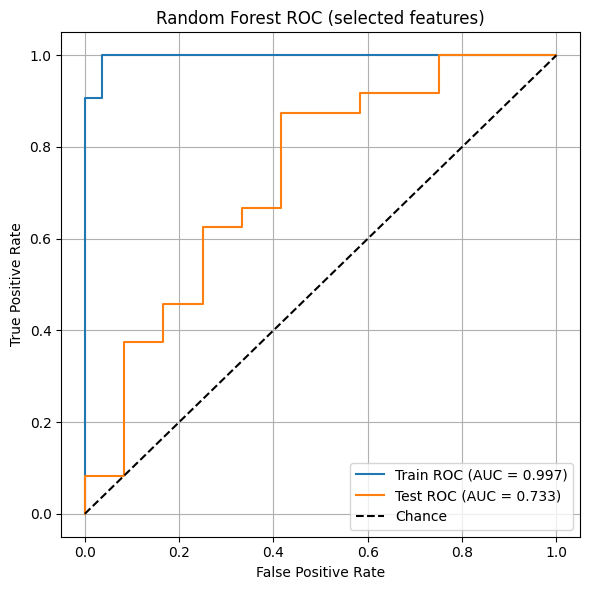

In [5]:
# ============================================
# 5. Plot ROC curves for TRAIN and TEST
# ============================================
fpr_tr, tpr_tr, _ = roc_curve(y_train, prob_tr)
fpr_te, tpr_te, _ = roc_curve(y_test,  prob_te)

plt.figure(figsize=(6, 6))
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC = {auc_tr:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC = {auc_te:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC (selected features)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
